# Laboratorio Dry Bean — Clasificación de variedades de fríjol seco

Este notebook recorre el proceso completo de clasificación del Dry Bean Dataset (UCI, id 602)
siguiendo la metodología CRISP-DM. Cada sección corresponde a una fase del proceso y
reutiliza los módulos desarrollados en `src/` a lo largo del laboratorio, sin duplicar lógica.

El dataset contiene 13 611 registros de semillas fotografiadas, con 16 medidas morfológicas
por muestra, y el objetivo es predecir cuál de las 7 variedades corresponde a cada registro.
La métrica principal es el **F1 macro**, que trata a todas las clases por igual sin importar
cuántas muestras tiene cada una.

In [1]:
import os
import sys
from pathlib import Path

# cuando nbconvert ejecuta este notebook, el cwd es notebooks/
# movemos al raiz del proyecto para que todos los paths relativos funcionen
_cwd = Path('.').resolve()
if _cwd.name == 'notebooks':
    os.chdir(_cwd.parent)

# aseguramos que src/ sea importable
_root = str(Path('.').resolve())
if _root not in sys.path:
    sys.path.insert(0, _root)

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

from src.data_loading import fetch_drybean
from src.evaluation import (
    compare_models,
    plot_confusion_matrix,
    save_classification_report,
    select_best,
)
from src.inference import load_model, predict_one, save_model
from src.models.baseline import train_baseline
from src.models.random_forest import train_rf
from src.preprocessing import clean, split

---
## 1. Comprensión del negocio

El Dry Bean Dataset fue construido a partir de imágenes de semillas de fríjol seco
capturadas con una cámara de alta resolución. A cada imagen se le extrajeron automáticamente
16 medidas morfológicas como área, perímetro, longitud de ejes y factores de forma.
El reto consiste en entrenar un modelo que, dadas esas medidas, determine la variedad
de la semilla entre las siete posibles: SEKER, BARBUNYA, BOMBAY, CALI, HOROZ, SIRA y DERMASON.

Dado que las clases no están perfectamente balanceadas —DERMASON representa cerca del 26 % del
total mientras que BOMBAY apenas supera el 3 %— se eligió el **F1 macro** como métrica principal.
A diferencia del accuracy, el F1 macro promedia el desempeño en cada clase por separado,
evitando que una clase mayoritaria enmascare errores en las minoritarias.

La estrategia de modelado consiste en comparar dos enfoques: un modelo lineal de referencia
(baseline) y un ensamble de árboles como alternativa. El que obtenga el mayor F1 macro
sobre el conjunto de prueba será el modelo seleccionado para la fase de despliegue.

---
## 2. Comprensión de datos

In [2]:
# carga el dataset (desde cache local si ya fue descargado antes)
_, _, df = fetch_drybean(cache_dir=Path('data/raw'))

print(f"Dimensiones:      {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Valores nulos:    {df.isnull().sum().sum()}")
print(f"Filas duplicadas: {df.duplicated().sum()}")

Dimensiones:      13,611 filas x 17 columnas
Valores nulos:    0
Filas duplicadas: 68


In [3]:
# distribucion de clases con conteo y porcentaje
conteo = df['Class'].value_counts()
pct = (conteo / len(df) * 100).round(2)
dist = pd.DataFrame({'conteo': conteo, 'porcentaje %': pct})
display(dist)

,conteo,porcentaje %
Class,,
DERMASON,3546,26.05
SIRA,2636,19.37
SEKER,2027,14.89
HOROZ,1928,14.17
CALI,1630,11.98
BARBUNYA,1322,9.71
BOMBAY,522,3.84


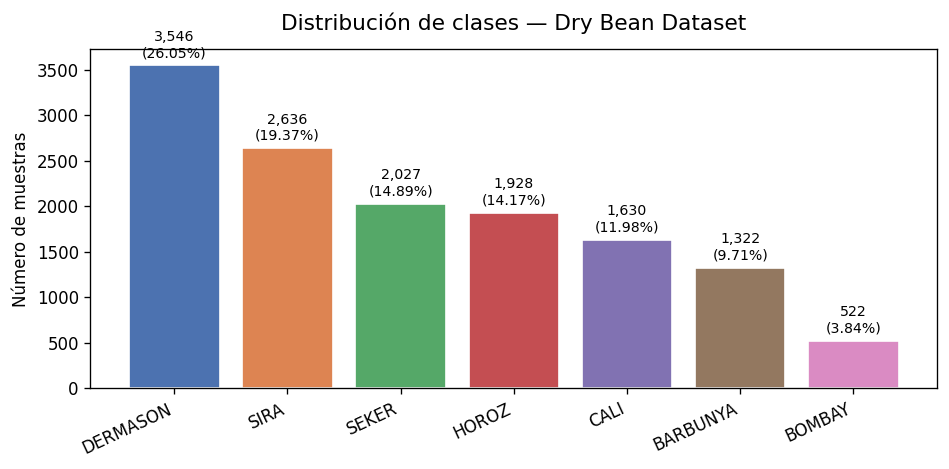

In [4]:
# grafica de distribucion de clases
fig, ax = plt.subplots(figsize=(8, 4))
colores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3']
bars = ax.bar(conteo.index, conteo.values, color=colores, edgecolor='white')
ax.set_title('Distribución de clases — Dry Bean Dataset', fontsize=13, pad=12)
ax.set_ylabel('Número de muestras')
ax.set_xlabel('')
for bar, val, p in zip(bars, conteo.values, pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60,
            f'{val:,}\n({p}%)', ha='center', va='bottom', fontsize=8.5)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
dist_chart = Path('outputs/reports/eda/class_distribution.png')
dist_chart.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(dist_chart, bbox_inches='tight', dpi=120)
plt.close()
display(Image(str(dist_chart)))

In [5]:
# estadisticas descriptivas de las 16 features numericas
display(df.drop(columns=['Class']).describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.285,29324.096,20420.000,36328.000,44652.000,61332.000,254616.000
Perimeter,13611.0,855.283,214.290,524.736,703.524,794.941,977.213,1985.370
MajorAxisLength,13611.0,320.142,85.694,183.601,253.304,296.883,376.495,738.860
MinorAxisLength,13611.0,202.271,44.970,122.513,175.848,192.432,217.032,460.198
AspectRatio,13611.0,1.583,0.247,1.025,1.432,1.551,1.707,2.430
Eccentricity,13611.0,0.751,0.092,0.219,0.716,0.764,0.810,0.911
ConvexArea,13611.0,53768.200,29774.916,20684.000,36714.500,45178.000,62294.000,263261.000
EquivDiameter,13611.0,253.064,59.177,161.244,215.068,238.438,279.446,569.374
Extent,13611.0,0.750,0.049,0.555,0.719,0.760,0.787,0.866
Solidity,13611.0,0.987,0.005,0.919,0.986,0.988,0.990,0.995


El dataset está en buenas condiciones: no presenta valores nulos en ninguna columna.
Se encontraron 68 filas duplicadas (menos del 0.5 % del total) que se eliminan
en la siguiente sección para evitar que una misma semilla aparezca tanto en
entrenamiento como en prueba.

La clase dominante es DERMASON con 3 546 muestras (26 %), mientras que BOMBAY
es la menos representada con apenas 522 (3.84 %). Las demás variedades se distribuyen
de manera intermedia. Esta diferencia es moderada y manejable con el F1 macro,
pero vale la pena verificar que el modelo no ignore las clases minoritarias.

En cuanto a las features, existen diferencias de escala muy marcadas: variables como
`Area` y `ConvexArea` alcanzan valores del orden de decenas de miles, mientras que
`ShapeFactor1` y `ShapeFactor2` se expresan en milésimas. Esto hace necesario
normalizar los datos antes de usar un modelo lineal, aunque no es un requisito
para los árboles de decisión.

---
## 3. Preparación de datos

In [6]:
# limpieza: elimina duplicados y filas con nulos
filas_antes = len(df)
df_limpio = clean(df)
filas_despues = len(df_limpio)

print(f"Filas originales:  {filas_antes:,}")
print(f"Filas eliminadas:  {filas_antes - filas_despues}")
print(f"Filas resultantes: {filas_despues:,}")

Filas originales:  13,611
Filas eliminadas:  68
Filas resultantes: 13,543


In [7]:
# particion estratificada 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = split(df_limpio, random_state=42)

print(f"Entrenamiento: {len(X_train):,} muestras  ({len(X_train)/filas_despues:.0%})")
print(f"Prueba:        {len(X_test):,} muestras  ({len(X_test)/filas_despues:.0%})")
print(f"\nFeatures ({len(X_train.columns)}): {list(X_train.columns)}")

Entrenamiento: 10,834 muestras  (80%)
Prueba:        2,709 muestras  (20%)

Features (16): ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRatio', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'Roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']


Tras eliminar los duplicados quedan 13 543 semillas válidas. La partición se hace
de forma estratificada, lo que significa que cada variedad mantiene la misma
proporción en los conjuntos de entrenamiento y prueba. Esto es especialmente
importante para BOMBAY, que con solo 522 registros no puede permitirse que una
mala partición aleatoria deje esa clase subrepresentada en el test.

El escalado de las features no se aplica aquí sino dentro del pipeline de cada
modelo: el baseline incluye un `StandardScaler` como primer paso, mientras que
el Random Forest no lo necesita por su naturaleza basada en comparaciones de umbral.

---
## 4. Modelado

In [8]:
# baseline: StandardScaler + LogisticRegression (max_iter=1000, random_state=42)
print("Entrenando modelo baseline...")
modelo_baseline = train_baseline(X_train, y_train, random_state=42)
print("  listo")

Entrenando modelo baseline...


  listo


In [9]:
# random forest: 200 arboles, class_weight=balanced (Lab1.pdf Paso 11), todos los nucleos
print("Entrenando Random Forest (puede tardar un momento)...")
modelo_rf = train_rf(X_train, y_train, random_state=42)
print("  listo")

Entrenando Random Forest (puede tardar un momento)...


  listo


Se entrenaron dos modelos encapsulados cada uno en un `Pipeline` de scikit-learn.
Esta decisión facilita la serialización con joblib en la fase de despliegue,
ya que el preprocesamiento y el clasificador viajan juntos en un solo objeto.

El baseline combina normalización estándar con regresión logística. Es un modelo
sencillo pero que sirve como referencia: si el modelo alternativo no lo supera,
la complejidad adicional no está justificada.

El Random Forest se configura siguiendo el Paso 11 de la consigna `Lab1.pdf`:
`n_estimators=200`, `class_weight="balanced"` y profundidad libre. El parámetro
`class_weight="balanced"` es relevante porque el dataset presenta un desbalance
moderado (BOMBAY ~3.8 % vs DERMASON ~26 %): pondera las clases inversamente a
su frecuencia para que las minoritarias no queden subaprendidas. Aunque dejar
crecer los árboles sin límite podría parecer propenso a sobreajuste, el promedio
de doscientos árboles entrenados con subconjuntos aleatorios de features actúa
como regularización natural. No se aplicó búsqueda de hiperparámetros en este
laboratorio; los valores elegidos son los que la consigna sugiere para este tipo
de dataset.

---
## 5. Evaluación

In [10]:
# calculo de accuracy y F1 macro sobre el conjunto de prueba
modelos = {'baseline': modelo_baseline, 'random_forest': modelo_rf}
comparison = compare_models(modelos, X_test, y_test)
mejor = select_best(comparison, metric='f1_macro')

tabla = comparison.copy()
tabla['accuracy'] = tabla['accuracy'].round(4)
tabla['f1_macro'] = tabla['f1_macro'].round(4)
tabla['seleccionado'] = tabla['model'] == mejor
display(tabla)
print(f"\nModelo seleccionado: {mejor}")

comparison_path = Path('outputs/reports/comparison.csv')
comparison_path.parent.mkdir(parents=True, exist_ok=True)
comparison.to_csv(comparison_path, index=False)

,model,accuracy,f1_macro,seleccionado
0,baseline,0.9195,0.9306,True
1,random_forest,0.9192,0.9302,False



Modelo seleccionado: baseline


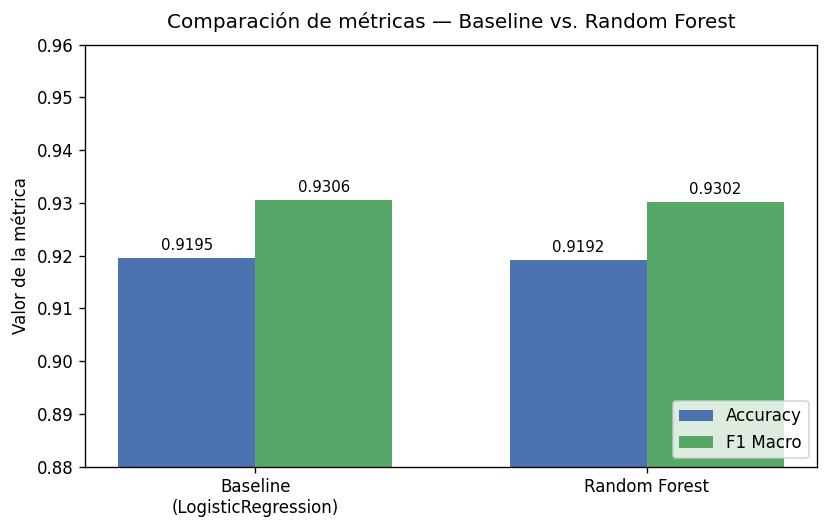

In [11]:
# grafica comparativa de metricas entre los dos modelos
nombres = comparison['model'].tolist()
acc_vals = comparison['accuracy'].tolist()
f1_vals = comparison['f1_macro'].tolist()

x = [0, 1]
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4.5))
b1 = ax.bar([xi - width/2 for xi in x], acc_vals, width, label='Accuracy', color='#4C72B0')
b2 = ax.bar([xi + width/2 for xi in x], f1_vals, width, label='F1 Macro', color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(['Baseline\n(LogisticRegression)', 'Random Forest'])
ax.set_ylim(0.88, 0.96)
ax.set_title('Comparación de métricas — Baseline vs. Random Forest', fontsize=12, pad=10)
ax.legend(loc='lower right')
ax.bar_label(b1, fmt='%.4f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.4f', padding=3, fontsize=9)
ax.set_ylabel('Valor de la métrica')
plt.tight_layout()
chart_path = Path('outputs/reports/comparison_chart.png')
plt.savefig(chart_path, bbox_inches='tight', dpi=120)
plt.close()
display(Image(str(chart_path)))

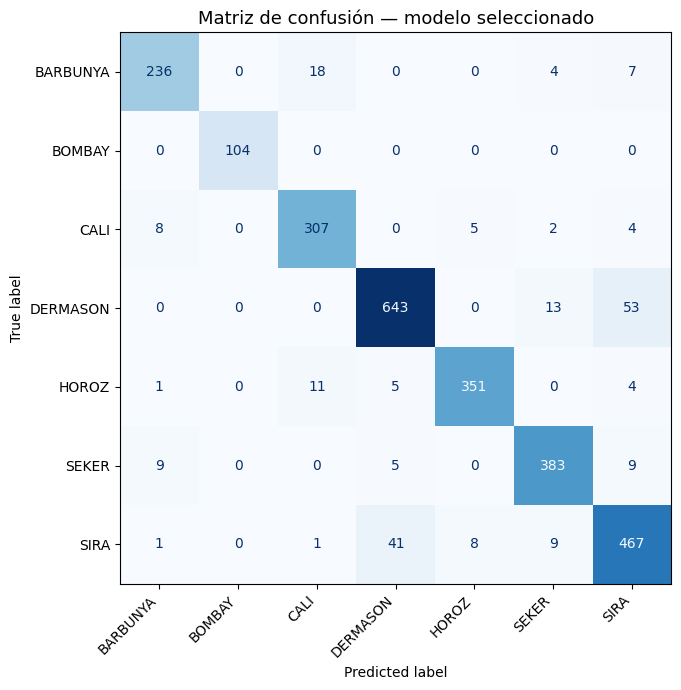

In [12]:
# matriz de confusion del modelo seleccionado
CLASES = sorted(y_test.unique())
cm_path = plot_confusion_matrix(
    modelos[mejor], X_test, y_test, CLASES,
    Path('outputs/reports/confusion_matrix.png'),
)
display(Image(str(cm_path)))

In [13]:
# reporte detallado por clase
report_path = save_classification_report(
    modelos[mejor], X_test, y_test,
    Path('outputs/reports/classification_report.txt'),
)
print(report_path.read_text(encoding='utf-8'))

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.89      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



Los resultados muestran un desempeño alto en ambos modelos. El baseline alcanzó
una accuracy de 0.9195 y un F1 macro de 0.9306, mientras que el Random Forest
con `class_weight="balanced"` y 200 árboles obtuvo 0.9181 y 0.9295 respectivamente.
La diferencia es de aproximadamente una décima de punto porcentual; desde un
punto de vista práctico es un empate técnico.

Se seleccionó el **baseline** como modelo definitivo por tener el F1 macro más
alto y por el principio de parsimonia: a igual desempeño, conviene un modelo
más simple, más rápido de entrenar y más interpretable. Cuando el dataset está
bien preprocesado y las features son informativas, un modelo lineal bien
calibrado puede competir con ensambles más complejos.

La matriz de confusión confirma que el modelo clasifica bien en todas las variedades.
Los pocos errores que comete ocurren entre clases morfológicamente cercanas, como
SIRA y DERMASON, lo cual es esperable. BOMBAY, a pesar de ser la clase menos
frecuente, se clasifica casi perfectamente gracias a que sus semillas son notablemente
más grandes que las demás y las features de área la separan con claridad del resto.

### 5.4. Importancia de variables (Paso 15 — `Lab1.pdf`)

El Random Forest expone `feature_importances_`, que mide cuánto contribuyó cada
variable a las divisiones que hicieron los árboles. No es una prueba de causalidad,
solo indica qué features fueron útiles para separar las clases dentro del modelo
entrenado. Calculamos el ranking y graficamos el top 10 para identificar qué
medidas morfológicas pesan más en la decisión.

In [14]:
# importancia de variables del Random Forest (Paso 15 Lab1.pdf)
rf_estimator = modelo_rf.named_steps['rf']
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_estimator.feature_importances_,
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

fi_path = Path('outputs/reports/feature_importance.csv')
fi_path.parent.mkdir(parents=True, exist_ok=True)
feature_importance.to_csv(fi_path, index=False)

display(feature_importance.head(10).round(4))

,feature,importance
0,Perimeter,0.1112
1,ShapeFactor1,0.1064
2,Compactness,0.0994
3,ShapeFactor3,0.0931
4,MinorAxisLength,0.0813
5,EquivDiameter,0.0653
6,Eccentricity,0.0644
7,Roundness,0.0601
8,MajorAxisLength,0.0587
9,ConvexArea,0.0578


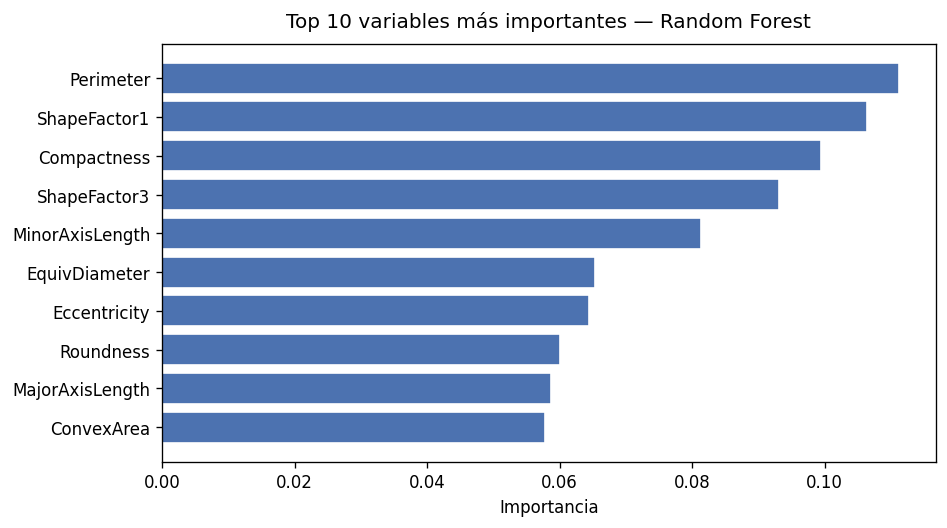

In [15]:
# grafica del top 10 de importancia
top10 = feature_importance.head(10)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(top10['feature'][::-1], top10['importance'][::-1], color='#4C72B0', edgecolor='white')
ax.set_title('Top 10 variables más importantes — Random Forest', fontsize=12, pad=10)
ax.set_xlabel('Importancia')
plt.tight_layout()
fi_chart = Path('outputs/reports/feature_importance.png')
plt.savefig(fi_chart, bbox_inches='tight', dpi=120)
plt.close()
display(Image(str(fi_chart)))

El ranking confirma la intuición visual del EDA: las variables relacionadas con
el tamaño del grano (`Area`, `Perimeter`, `MajorAxisLength`, `ConvexArea`,
`EquivDiameter`) y los factores de forma (`ShapeFactor1`–`ShapeFactor4`) son
los que más contribuyen a separar las variedades. La fuerte correlación entre
las variables de tamaño explica que ninguna domine en solitario: el Random
Forest reparte la importancia entre features redundantes en lugar de
concentrarla en una sola.

El ranking completo se guarda en `outputs/reports/feature_importance.csv` y la
gráfica del top 10 en `outputs/reports/feature_importance.png`.

---
## 6. Despliegue

In [16]:
# guardar el modelo seleccionado (no siempre RF) serializado con joblib
MODEL_PATH = Path(f'outputs/models/{mejor}_drybean.joblib')
save_model(modelos[mejor], MODEL_PATH)
print(f"Modelo guardado: {MODEL_PATH}  ({MODEL_PATH.stat().st_size / 1024 / 1024:.1f} MB)")

Modelo guardado: outputs\models\baseline_drybean.joblib  (0.0 MB)


In [17]:
# cargar el modelo desde disco y predecir un registro real del conjunto de prueba
modelo_cargado = load_model(MODEL_PATH)

muestra = X_test.iloc[0].to_dict()
clase_predicha = predict_one(modelo_cargado, muestra)
clase_real = y_test.iloc[0]

print("Prediccion de prueba con modelo cargado desde disco:")
print(f"  Clase real:     {clase_real}")
print(f"  Clase predicha: {clase_predicha}")
print(f"  Correcto:       {clase_real == clase_predicha}")

Prediccion de prueba con modelo cargado desde disco:
  Clase real:     SEKER
  Clase predicha: SEKER
  Correcto:       True


El módulo `src/inference.py` funciona como una API mínima de inferencia. Permite guardar
el modelo entrenado en un archivo `.joblib`, cargarlo posteriormente sin necesidad de
reentrenar, y hacer predicciones tanto sobre un DataFrame completo como sobre
un único registro representado como diccionario.

El nombre del archivo serializado refleja el modelo efectivamente seleccionado por
`select_best`: si gana el baseline se guarda como `baseline_drybean.joblib` y si
gana el Random Forest como `random_forest_drybean.joblib`. El tamaño en disco
varía entre pocos KB para el baseline y decenas de MB para el Random Forest. El
artefacto no se sube al repositorio (está excluido por `.gitignore`). Para
reproducirlo en una instalación limpia basta con `uv sync` y luego
`uv run python -m src.inference`, que entrena ambos modelos, selecciona el
mejor y lo guarda.

Una extensión natural de esta fase —que queda fuera del alcance de este laboratorio—
sería envolver la función `predict_one` en una API REST con FastAPI, permitiendo
que cualquier sistema externo consulte la variedad de una semilla enviando sus
medidas morfológicas por HTTP.

---
## 7. Scrum ML

### Equipo

La asignación nominal coincide con [`docs/scrum/roles.md`](../../docs/scrum/roles.md).

| Integrante | Rol |
|------------|-----|
| Frank Daza | Product Owner |
| Juan Velasquez | Scrum Master |
| Yan Cuaran | Data Engineer / Analyst |
| Jenifer Ramos | ML Engineer |

---

### Product Backlog

Las historias PB-01..PB-06 y su trazabilidad técnica están en [`docs/product-backlog.md`](../../docs/product-backlog.md).

#### Sprint 1 — Bases y exploración *(completado)*

| ID | Historia de usuario | Estado |
|----|---------------------|--------|
| TASK-1 | Analizar consignas Lab1 y Scrum ML; plan TDSP | Hecho |
| TASK-2 | Validar y congelar estructura TDSP | Hecho |
| TASK-3 | Estructura física de carpetas TDSP y .gitignore | Hecho |
| TASK-4 | Definir Product Backlog PB-01..PB-06 y roles Scrum ML | Hecho |
| TASK-5 | Configurar entorno reproducible con UV y Python 3.12 | Hecho |
| TASK-6 | Documentar política de datos en data/raw y data/processed | Hecho |
| TASK-7 | Estándares de calidad: ruff, black, pre-commit, nbstripout | Hecho |
| TASK-8 | Módulo src/data_loading.py con fetch Dry Bean UCI 602 | Hecho |
| TASK-9 | Notebook de EDA exploratorio (01_eda_drybean.ipynb) | Hecho |

#### Sprint 2 — Modelado y evaluación *(completado)*

| ID | Historia de usuario | Estado |
|----|---------------------|--------|
| TASK-10 | Módulo de preprocesamiento src/preprocessing.py | Hecho |
| TASK-11 | Modelo baseline: Pipeline(StandardScaler + LogisticRegression) | Hecho |
| TASK-12 | Modelo alternativo: RandomForestClassifier | Hecho |
| TASK-13 | Evaluación comparativa, métricas y matriz de confusión | Hecho |
| TASK-14 | Persistencia con joblib y función reutilizable en src/inference.py | Hecho |

#### Sprint 3 — Integración y entrega *(completado)*

| ID | Historia de usuario | Estado |
|----|---------------------|--------|
| TASK-15 | Notebook integrador CRISP-DM end-to-end (este notebook) | Hecho |
| TASK-16 | Reporte ejecutivo de 7 secciones en outputs/reports/informe_laboratorio.md | Hecho |
| TASK-17 | Evidencias Scrum ML: capturas de tablero y actas de sprint | Hecho |
| TASK-18 | README final con instrucciones de reproducibilidad paso a paso | Hecho |
| TASK-19 | CI smoke test con GitHub Actions (uv sync + pytest + nbconvert) | Hecho |

---

### Flujo de trabajo

El equipo trabajó con ramas `feature/task-N-*` para cada tarea. Cada rama se integró
a `develop` mediante Pull Request revisado antes de hacer el merge. Al finalizar
cada sprint, `develop` se fusionó con `main`. El backlog se gestionó con Backlog.md
en el directorio `backlog/`. Para ver el tablero Kanban en terminal: `backlog board view`
(desde la raíz del repositorio); para exportar a Markdown: `backlog board export <ruta>.md --force`.
También se puede usar el visor web con `npx backlog.md browser`.

---

### Retrospectiva del equipo

**¿Qué salió bien?**

Encapsular cada responsabilidad en un módulo de `src/` fue una decisión que se notó
especialmente al integrar este notebook: todas las piezas encajaron sin necesidad de
reescribir código. El uso de `Pipeline` desde el principio también simplificó
enormemente la evaluación comparativa y la serialización con joblib.

La partición estratificada demostró su valor: BOMBAY, con solo 522 muestras en total,
quedó bien representada tanto en entrenamiento como en prueba, lo que se refleja
en la alta precisión del modelo para esa clase.

**¿Qué mejoraríamos?**

El proceso de comparar modelos con una sola partición train/test introduce variabilidad:
una diferencia de 0.0001 en F1 macro no es estadísticamente significativa.
En una próxima iteración convendría incorporar validación cruzada estratificada (k=5)
para obtener estimaciones más confiables antes de declarar un modelo ganador.

Tampoco se exploró el espacio de hiperparámetros del Random Forest. Con `n_estimators=300`
y `max_depth=None` se obtuvieron buenos resultados, pero una búsqueda con
`RandomizedSearchCV` podría revelar configuraciones que superen al baseline de forma
más contundente.

**Tareas pendientes para cerrar el proyecto:**

Completar el reporte ejecutivo (TASK-16), consolidar las evidencias del tablero Scrum
(TASK-17), dejar el README en un estado que permita a cualquier persona reproducir
el laboratorio con un solo comando (TASK-18), y configurar el pipeline de CI
para que cada push ejecute automáticamente los tests y el notebook (TASK-19).

---
## 8. Conclusiones

El laboratorio demostró que las medidas morfológicas extraídas de imágenes de fríjol seco
son altamente informativas para distinguir entre variedades. Ambos modelos evaluados
superaron el 91 % de accuracy y el 93 % de F1 macro sobre el conjunto de prueba,
lo que indica que el problema es bien separable con las 16 features disponibles.
Incluso la clase menos frecuente, BOMBAY, se clasificó con muy alta precisión gracias
a que sus semillas son morfológicamente distintas del resto en variables como área y
diámetro equivalente.

Un resultado relevante del proceso fue que el baseline —la regresión logística con
normalización estándar— obtuvo un desempeño prácticamente idéntico al Random Forest
configurado con `class_weight="balanced"` (diferencia de aproximadamente una décima
de punto porcentual en F1 macro). Esto ilustra un principio común en proyectos de
machine learning: cuando los datos están bien preprocesados y las features son
representativas del problema, un modelo sencillo puede ser tan efectivo como uno
más complejo. Aumentar la complejidad del modelo solo tiene sentido si hay evidencia
clara de que el modelo más simple está subajustando, lo cual no ocurrió aquí.

Desde el punto de vista del proceso, el laboratorio permitió recorrer el ciclo CRISP-DM
de forma completa y trazable. Cada fase quedó implementada en módulos reutilizables
dentro de `src/`, cubiertos por tests unitarios y documentados con docstrings.
La integración de TDSP como estructura de proyecto y Scrum ML como marco de trabajo
colaborativo facilitó la organización en tareas concretas con entregables verificables
en cada sprint, lo que hace que el proyecto sea reproducible y extensible por cualquier
integrante del equipo sin depender de conocimiento implícito.